# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang digunakan dalam proyek ini adalah **heart.csv** yang bertujuan untuk memprediksi apakah seorang pasien memiliki penyakit jantung berdasarkan atribut medis tertentu.

* **Sumber Dataset**: [Kaggle - Heart.csv](https://www.kaggle.com/datasets/arezaei81/heartcsv)
* **Format File**: `heart.csv`
* **Jumlah Data**: 303 baris dan 14 kolom.

### Atribut/Fitur Dataset:
1. **Age**: Usia pasien.
2. **Sex**: Jenis kelamin (1 = laki-laki; 0 = perempuan).
3. **CP (Chest Pain Type)**: Tipe nyeri dada (4 nilai).
4. **Trestbps**: Tekanan darah istirahat.
5. **Chol**: Kolesterol serum dalam mg/dl.
6. **Fbs**: Gula darah puasa > 120 mg/dl (1 = true; 0 = false).
7. **Restecg**: Hasil elektrokardiografi istirahat (nilai 0,1,2).
8. **Thalach**: Detak jantung maksimum yang dicapai.
9. **Exang**: Angina akibat olahraga (1 = ya; 0 = tidak).
10. **Oldpeak**: Depresi ST yang diinduksi oleh olahraga relatif terhadap istirahat.
11. **Slope**: Kemiringan segmen ST latihan puncak.
12. **CA**: Jumlah pembuluh darah utama (0-3) yang diwarnai dengan flourosopy.
13. **Thal**: 3 = normal; 6 = cacat tetap; 7 = cacat yang dapat diperbaiki.
14. **Target (Label)**: Diagnosis penyakit jantung (1 = sakit; 0 = sehat).


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [14]:
import os
from google.colab import files

# 1. Buat folder
os.makedirs('../namadataset_raw', exist_ok=True)
os.makedirs('namadataset_preprocessing', exist_ok=True)

# 2. Unggah file dataset heart.csv
print("Silakan pilih file heart.csv dari komputer Anda:")
uploaded = files.upload()

# 3. Pindahkan file yang diunggah ke folder raw
for filename in uploaded.keys():
    os.rename(filename, f'../namadataset_raw/{filename}')
    print(f"File {filename} berhasil dipindahkan ke folder namadataset_raw")

# Memuat data dari folder dataset
df = pd.read_csv('../namadataset_raw/heart.csv')

# Menampilkan 5 data teratas
df.head()

Silakan pilih file heart.csv dari komputer Anda:


Saving heart.csv to heart.csv
File heart.csv berhasil dipindahkan ke folder namadataset_raw


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

 Jumlah Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


/tmp/ipython-input-3467730240.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


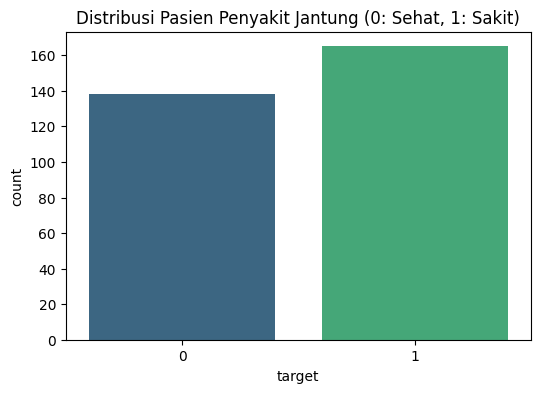

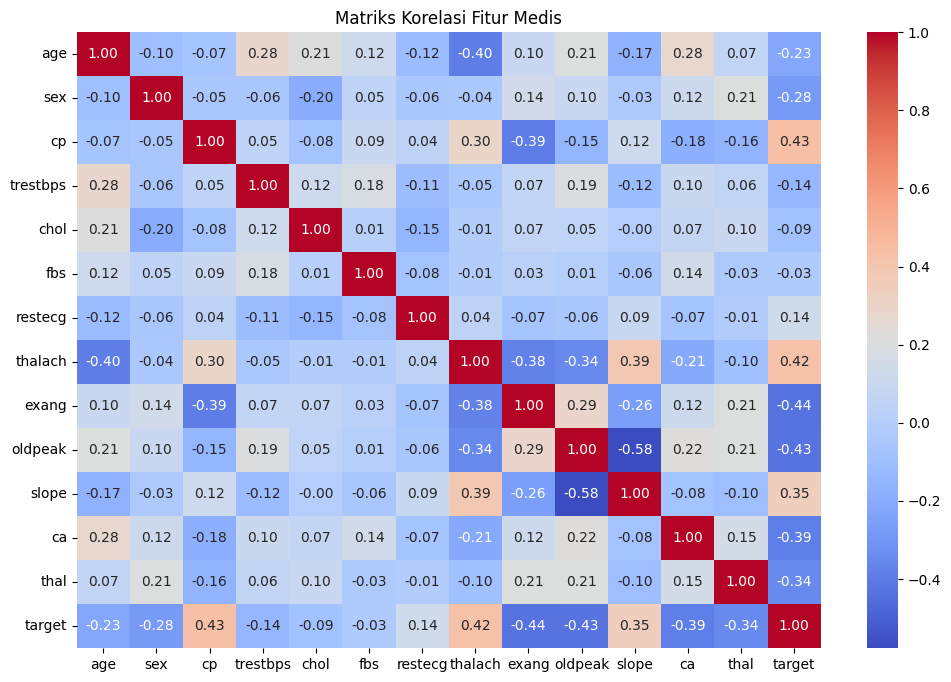

In [15]:
# 1. Informasi struktur data
print("Informasi Dataset")
print(df.info())

# 2. Mengecek Missing Values
print("\n Jumlah Missing Values")
print(df.isnull().sum())

# 3. Statistik Deskriptif
print("\n Statistik Deskriptif")
display(df.describe())

# 4. Visualisasi Distribusi Target
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribusi Pasien Penyakit Jantung (0: Sehat, 1: Sakit)')
plt.show()

# 5. Korelasi antar Fitur
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur Medis')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [16]:
# 1. Menghapus data duplikat jika ada
df = df.drop_duplicates()

# 2. Standarisasi Fitur Numerik
# Fitur numerik yang perlu diskalakan agar model bekerja optimal
scaler = StandardScaler()
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

df[num_cols] = scaler.fit_transform(df[num_cols])

# 3. Menampilkan hasil preprocessing
print("Data Setelah Preprocessing")
display(df.head())

# 4. Menyimpan data hasil preprocessing untuk Kriteria 2
df.to_csv('namadataset_preprocessing/cleaned_heart.csv', index=False)

Data Setelah Preprocessing


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.949794,1,3,0.764066,-0.261285,1,0,0.018826,0,1.084022,0,0,1,1
1,-1.928548,1,2,-0.091401,0.067741,0,1,1.636979,0,2.118926,0,0,2,1
2,-1.485726,0,1,-0.091401,-0.822564,0,0,0.980971,0,0.307844,2,0,2,1
3,0.174856,1,1,-0.661712,-0.203222,0,1,1.243374,0,-0.209608,2,0,2,1
4,0.285561,0,0,-0.661712,2.080602,0,1,0.587366,1,-0.382092,2,0,2,1
